# Leitos hospitalares por município

**Pergunta que este notebook responde:** quais municípios do estado têm mais
leitos, e quantos deles estão disponíveis para o SUS?

**Fonte:** CNES — Cadastro Nacional de Estabelecimentos de Saúde, grupo `LT`
(leitos), publicado mensalmente pelo DATASUS.
**Tempo estimado:** 3 a 5 minutos.

> Para adaptar ao seu estado, mude a sigla em `UF` na célula de parâmetros.

## Preparação

Toda análise começa por aqui: instalar as bibliotecas e aplicar o `nest_asyncio`,
sem o qual a PySUS não funciona dentro de um notebook.

In [2]:
%pip install pysus nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros da análise

Tudo o que você pode querer mudar está reunido aqui. Comece com um mês só —
o download é rápido e o resultado já é útil.

In [3]:
UF = "PR"        # sigla do estado (ex.: "SP", "CE", "AM")
ANO = 2024
MES = 12         # dezembro

## Conferindo se o período existe

Antes de baixar, confirmamos que o arquivo está publicado. Se não estiver, a
biblioteca devolveria uma tabela vazia sem avisar.

In [4]:
from pysus import list_files

catalogo = list_files(dataset="cnes", state=UF, year=ANO, month=MES)
print(f"Arquivos disponíveis para {UF} em {MES:02d}/{ANO}: {len(catalogo)}")

if len(catalogo) == 0:
    print("⚠ Esse período ainda não foi publicado. Tente um mês anterior.")

Arquivos disponíveis para PR em 12/2024: 12


## Baixando os leitos

O parâmetro `group="LT"` é essencial: ele traz **só** a tabela de leitos. Sem
ele, o CNES devolve todos os grupos juntos — mais de 30 mil linhas e 362
colunas.

In [5]:
from pysus import cnes

leitos = cnes(state=UF, year=ANO, month=MES, group="LT", as_dataframe=True)

print(f"{len(leitos):,} registros de leitos em {UF}, {MES:02d}/{ANO}")

3,261 registros de leitos em PR, 12/2024


## Somando os leitos por município

Cada linha traz um tipo de leito de um estabelecimento. Para chegar ao total do
município, convertemos as quantidades para número e somamos por `CODUFMUN`
(o código IBGE do município).

In [6]:
import pandas as pd

leitos["QT_EXIST"] = pd.to_numeric(leitos["QT_EXIST"], errors="coerce").fillna(0)
leitos["QT_SUS"] = pd.to_numeric(leitos["QT_SUS"], errors="coerce").fillna(0)

por_municipio = (
    leitos.groupby("CODUFMUN")[["QT_EXIST", "QT_SUS"]]
    .sum()
    .sort_values("QT_EXIST", ascending=False)
    .reset_index()
)

por_municipio["% SUS"] = (
    por_municipio["QT_SUS"] / por_municipio["QT_EXIST"] * 100
).round(1)

print(f"Municípios com leitos cadastrados: {len(por_municipio)}")
por_municipio.head(10)

Municípios com leitos cadastrados: 243


,CODUFMUN,QT_EXIST,QT_SUS,% SUS
0,410690,6177,3122,50.5
1,411370,2486,1508,60.7
2,411520,1845,843,45.7
3,410420,1372,1292,94.2
4,410480,1251,782,62.5
5,411990,952,655,68.8
6,412810,796,620,77.9
7,411950,726,501,69.0
8,410830,636,373,58.6
9,410940,620,457,73.7


### De código para nome do município

O DATASUS identifica municípios pelo código do IBGE (6 dígitos). Para exibir os
nomes, buscamos a tabela oficial do IBGE — que é pública e não exige cadastro.

In [7]:
import pandas as pd

URL_IBGE = "https://servicodados.ibge.gov.br/api/v1/localidades/municipios"

try:
    municipios = pd.read_json(URL_IBGE)
    nomes = {
        str(m["id"])[:6]: m["nome"]
        for _, m in municipios.iterrows()
    }
    por_municipio["Município"] = por_municipio["CODUFMUN"].map(nomes)
    print("Nomes carregados do IBGE.")
except Exception as erro:
    por_municipio["Município"] = por_municipio["CODUFMUN"]
    print("Não consegui buscar os nomes agora; sigo com os códigos.", erro)

por_municipio.head(10)

Nomes carregados do IBGE.


,CODUFMUN,QT_EXIST,QT_SUS,% SUS,Município
0,410690,6177,3122,50.5,Curitiba
1,411370,2486,1508,60.7,Londrina
2,411520,1845,843,45.7,Maringá
3,410420,1372,1292,94.2,Campo Largo
4,410480,1251,782,62.5,Cascavel
5,411990,952,655,68.8,Ponta Grossa
6,412810,796,620,77.9,Umuarama
7,411950,726,501,69.0,Piraquara
8,410830,636,373,58.6,Foz do Iguaçu
9,410940,620,457,73.7,Guarapuava


## Os 10 municípios com mais leitos

In [8]:
top10 = por_municipio.head(10)[["Município", "QT_EXIST", "QT_SUS", "% SUS"]]
top10 = top10.rename(columns={"QT_EXIST": "Leitos totais", "QT_SUS": "Leitos SUS"})
top10.reset_index(drop=True)

,Município,Leitos totais,Leitos SUS,% SUS
0,Curitiba,6177,3122,50.5
1,Londrina,2486,1508,60.7
2,Maringá,1845,843,45.7
3,Campo Largo,1372,1292,94.2
4,Cascavel,1251,782,62.5
5,Ponta Grossa,952,655,68.8
6,Umuarama,796,620,77.9
7,Piraquara,726,501,69.0
8,Foz do Iguaçu,636,373,58.6
9,Guarapuava,620,457,73.7


## Em gráfico

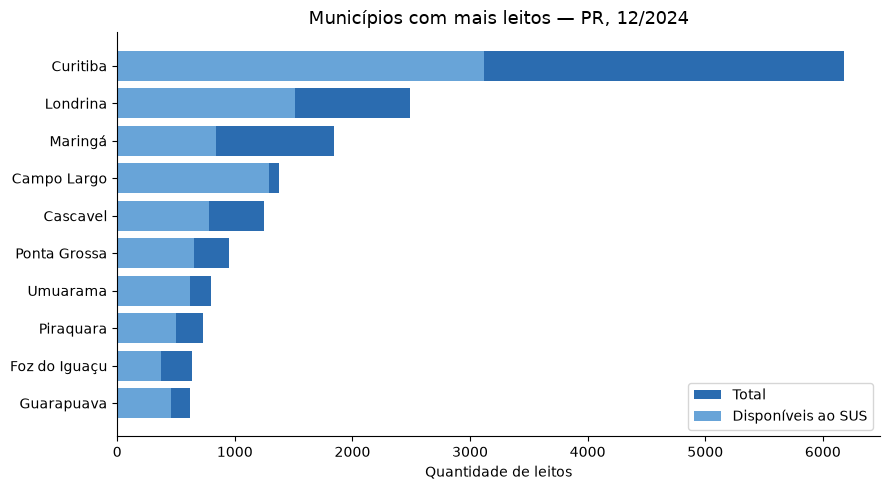

In [9]:
import matplotlib.pyplot as plt

grafico = top10.sort_values("Leitos totais")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(grafico["Município"].astype(str), grafico["Leitos totais"],
        color="#2b6cb0", label="Total")
ax.barh(grafico["Município"].astype(str), grafico["Leitos SUS"],
        color="#68a4d8", label="Disponíveis ao SUS")

ax.set_title(f"Municípios com mais leitos — {UF}, {MES:02d}/{ANO}", fontsize=13)
ax.set_xlabel("Quantidade de leitos")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Resumo do estado

In [10]:
total = por_municipio["QT_EXIST"].sum()
total_sus = por_municipio["QT_SUS"].sum()

print(f"Estado: {UF} — {MES:02d}/{ANO}")
print(f"Leitos cadastrados:      {total:>10,.0f}")
print(f"Disponíveis para o SUS:  {total_sus:>10,.0f}  ({total_sus/total:.1%})")
print(f"Municípios com leitos:   {len(por_municipio):>10,}")

Estado: PR — 12/2024
Leitos cadastrados:          31,713
Disponíveis para o SUS:      21,898  (69.1%)
Municípios com leitos:          243


## Como adaptar

- **Outro estado:** mude `UF` na célula de parâmetros.
- **Outro mês:** mude `ANO` e `MES` (confira antes no catálogo).
- **Tipo de leito:** a coluna `TP_LEITO` separa cirúrgico, clínico, obstétrico,
  UTI etc. Você pode filtrar antes de somar.
- **Só leitos de UTI:** filtre `CODLEITO` pelos códigos de UTI antes do
  agrupamento.

---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*